# Racist/Sexist Tweet Classification using RNN, LSTM and Pretrained Embeddings

**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Task:** Part III – Language Task  
**Dataset:** Racist Sexist or Not Dataset

This notebook presents a complete NLP classification workflow for identifying whether a tweet is racist/sexist or non-racist/non-sexist. The work follows the assessment requirement for Task 3 by applying text cleaning, tokenization, sequence padding, model training, model comparison, error analysis and a simple real-time prediction interface.

Three models are implemented:

1. **Simple RNN** with a trainable embedding layer  
2. **LSTM** with a trainable embedding layer  
3. **LSTM** with pretrained GloVe/Word2Vec-style embeddings from `gensim`

The aim is to compare whether a more advanced recurrent architecture and pretrained semantic representations improve classification performance on short social-media text.

## 1. Environment Setup

The following cell imports the libraries required for data handling, preprocessing, model development and evaluation. A fixed random seed is used so that the train-test split and model initialization are more reproducible.

In [25]:
# Core utilities
import os
import re
import time
import random
import zipfile
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# Data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# NLTK preprocessing resources
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Reproducibility
RANDOM_STATE_VALUE = 77
np.random.seed(RANDOM_STATE_VALUE)
random.seed(RANDOM_STATE_VALUE)
tf.random.set_seed(RANDOM_STATE_VALUE)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: []


## 2. Dataset Upload and Loading

This version avoids Google Drive authentication. Upload the dataset zip manually in Colab using either the file browser on the left side or the upload prompt in the next cell. The notebook then extracts the training and testing CSV files automatically.

In [26]:
# Manual upload loader for Google Colab
# Expected zip name: 7. Racist Sexist or Not Dataset-20260508T103027Z-3-001.zip

from pathlib import Path

WORKSPACE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
RAW_ARCHIVE = WORKSPACE_DIR / "7. Racist Sexist or Not Dataset-20260508T103027Z-3-001.zip"
UNZIP_LOCATION = WORKSPACE_DIR / "racist_sexist_dataset"

if not RAW_ARCHIVE.exists():
    try:
        from google.colab import files
        print("Please upload the dataset zip file now.")
        uploaded_items = files.upload()
        for uploaded_name in uploaded_items.keys():
            uploaded_path = WORKSPACE_DIR / uploaded_name
            if uploaded_path.suffix.lower() == ".zip":
                RAW_ARCHIVE = uploaded_path
                break
    except Exception as upload_error:
        print("Manual upload prompt is not available in this environment:", upload_error)

print("Archive selected:", RAW_ARCHIVE)
assert RAW_ARCHIVE.exists(), "Dataset zip was not found. Upload the zip file before continuing."

if not UNZIP_LOCATION.exists():
    with zipfile.ZipFile(RAW_ARCHIVE, "r") as zip_ref:
        zip_ref.extractall(UNZIP_LOCATION)
    print("Dataset extracted to:", UNZIP_LOCATION)
else:
    print("Dataset folder already exists:", UNZIP_LOCATION)

csv_files_found = sorted(UNZIP_LOCATION.rglob("*.csv"))
print("CSV files detected:")
for item in csv_files_found:
    print(" -", item)

Archive selected: /content/7. Racist Sexist or Not Dataset-20260508T103027Z-3-001.zip
Dataset folder already exists: /content/racist_sexist_dataset
CSV files detected:
 - /content/racist_sexist_dataset/7. Racist Sexist or Not Dataset/test_racisit.csv
 - /content/racist_sexist_dataset/7. Racist Sexist or Not Dataset/train_racisit.csv


In [27]:
# Locate train and test files
TRAIN_CSV_FILE = next(path for path in csv_files_found if "train" in path.name.lower())
TEST_CSV_FILE = next(path for path in csv_files_found if "test" in path.name.lower())

raw_train_table = pd.read_csv(TRAIN_CSV_FILE)
unseen_test_table = pd.read_csv(TEST_CSV_FILE)

print("Training data shape:", raw_train_table.shape)
print("Unlabelled test data shape:", unseen_test_table.shape)
print("Training columns:", raw_train_table.columns.tolist())
print("Test columns:", unseen_test_table.columns.tolist())

raw_train_table.head()

Training data shape: (31962, 3)
Unlabelled test data shape: (17197, 2)
Training columns: ['id', 'label', 'tweet']
Test columns: ['id', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## 3. Initial Dataset Analysis

Before preprocessing, the dataset is inspected for missing values, class balance and tweet length. This helps identify whether imbalance handling is required and whether the text sequence length should be capped during padding.

In [28]:
# Basic dataset quality checks
print("Dataset size:", len(raw_train_table))
print("Missing values by column:")
print(raw_train_table.isna().sum())

label_count_series = raw_train_table["label"].value_counts().sort_index()
label_percent_series = (raw_train_table["label"].value_counts(normalize=True).sort_index() * 100).round(2)

summary_table = pd.DataFrame({
    "Class Label": label_count_series.index,
    "Number of Tweets": label_count_series.values,
    "Percentage": label_percent_series.values,
})
summary_table["Meaning"] = summary_table["Class Label"].map({0: "Non-racist / non-sexist", 1: "Racist / sexist"})
summary_table

Dataset size: 31962
Missing values by column:
id       0
label    0
tweet    0
dtype: int64


,Class Label,Number of Tweets,Percentage,Meaning
0,0,29720,92.99,Non-racist / non-sexist
1,1,2242,7.01,Racist / sexist


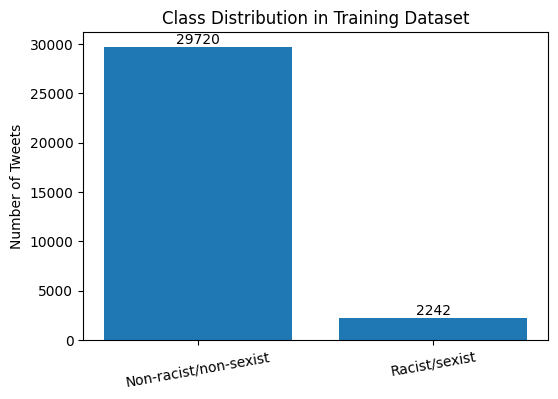

In [29]:
# Class distribution plot
plt.figure(figsize=(6, 4))
plt.bar(["Non-racist/non-sexist", "Racist/sexist"], label_count_series.values)
plt.title("Class Distribution in Training Dataset")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=10)
for index, value in enumerate(label_count_series.values):
    plt.text(index, value, str(value), ha="center", va="bottom")
plt.show()

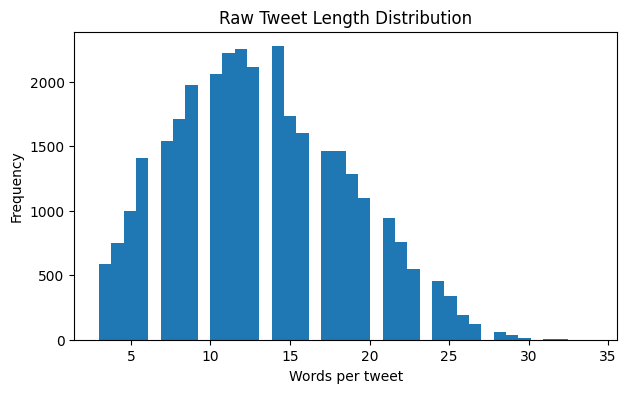

,raw_character_count,raw_word_count
count,31962.000000,31962.00000
mean,84.739628,13.15872
std,29.455749,5.47815
min,11.000000,3.00000
25%,63.000000,9.00000
50%,88.000000,13.00000
75%,108.000000,17.00000
max,274.000000,34.00000


In [30]:
# Add raw length fields for exploration
analysis_table = raw_train_table.copy()
analysis_table["raw_character_count"] = analysis_table["tweet"].astype(str).str.len()
analysis_table["raw_word_count"] = analysis_table["tweet"].astype(str).str.split().str.len()

plt.figure(figsize=(7, 4))
plt.hist(analysis_table["raw_word_count"], bins=40)
plt.title("Raw Tweet Length Distribution")
plt.xlabel("Words per tweet")
plt.ylabel("Frequency")
plt.show()

analysis_table[["raw_character_count", "raw_word_count"]].describe()

In [31]:
print("Examples labelled 0: non-racist/non-sexist")
for example in raw_train_table[raw_train_table["label"] == 0]["tweet"].head(3):
    print("-", example)

print("\nExamples labelled 1: racist/sexist")
for example in raw_train_table[raw_train_table["label"] == 1]["tweet"].head(3):
    print("-", example)

Examples labelled 0: non-racist/non-sexist
-  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
- @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
-   bihday your majesty

Examples labelled 1: racist/sexist
- @user #cnn calls #michigan middle school 'build the wall' chant '' #tcot  
- no comment!  in #australia   #opkillingbay #seashepherd #helpcovedolphins #thecove  #helpcovedolphins
- retweet if you agree! 


## 4. Text Cleaning and Normalization

The cleaning function standardizes tweets by lowercasing text, expanding common contractions, removing URLs, mentions, hashtag symbols, digits and special characters, removing stopwords and lemmatizing tokens. These steps reduce noisy social-media patterns while preserving meaningful words for classification.

In [32]:
CONTRACTION_LOOKUP = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "could've": "could have", "couldn't": "could not", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would", "he'll": "he will", "he's": "he is",
    "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "isn't": "is not", "it's": "it is", "let's": "let us", "mightn't": "might not",
    "mustn't": "must not", "shan't": "shall not", "she'd": "she would", "she'll": "she will",
    "she's": "she is", "should've": "should have", "shouldn't": "should not",
    "that's": "that is", "there's": "there is", "they'd": "they would", "they'll": "they will",
    "they're": "they are", "they've": "they have", "wasn't": "was not", "we'd": "we would",
    "we're": "we are", "weren't": "were not", "what's": "what is", "won't": "will not",
    "would've": "would have", "wouldn't": "would not", "you're": "you are", "you've": "you have",
}

STOP_WORD_SET = set(stopwords.words("english"))
# Keep negations because they can change meaning in hate-speech context.
STOP_WORD_SET = STOP_WORD_SET.difference({"no", "not", "nor"})
LEMMATIZER = WordNetLemmatizer()


def expand_short_forms(text_value):
    """Replace frequent English contractions with expanded forms."""
    words = str(text_value).split()
    return " ".join(CONTRACTION_LOOKUP.get(word, word) for word in words)


def normalize_tweet_text(tweet_text):
    """Clean one tweet and return a space-separated normalized string."""
    tweet_text = str(tweet_text).lower()
    tweet_text = expand_short_forms(tweet_text)
    tweet_text = re.sub(r"http\S+|www\.\S+", " ", tweet_text)
    tweet_text = re.sub(r"@\w+", " ", tweet_text)
    tweet_text = re.sub(r"#", " ", tweet_text)
    tweet_text = re.sub(r"[^a-z\s]", " ", tweet_text)
    tweet_text = re.sub(r"\s+", " ", tweet_text).strip()

    cleaned_tokens = []
    for token in tweet_text.split():
        if token not in STOP_WORD_SET and len(token) > 1:
            cleaned_tokens.append(LEMMATIZER.lemmatize(token))
    return " ".join(cleaned_tokens)

In [33]:
processed_tweet_table = raw_train_table.copy()
processed_tweet_table["clean_message"] = processed_tweet_table["tweet"].apply(normalize_tweet_text)

rows_before_filtering = len(processed_tweet_table)
processed_tweet_table = processed_tweet_table[processed_tweet_table["clean_message"].str.len() > 0].reset_index(drop=True)
rows_removed = rows_before_filtering - len(processed_tweet_table)

print("Rows removed after cleaning:", rows_removed)
print("Remaining rows:", len(processed_tweet_table))
processed_tweet_table[["tweet", "clean_message", "label"]].head()

Rows removed after cleaning: 35
Remaining rows: 31927


,tweet,clean_message,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cannot use cause not offer ...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love take time ur,0
4,factsguide: society now #motivation,factsguide society motivation,0


## 5. Cleaned Text Visualization

The most frequent words are shown separately for each class. This provides a quick view of terms that appear repeatedly in non-racist/non-sexist tweets and in racist/sexist tweets after cleaning.

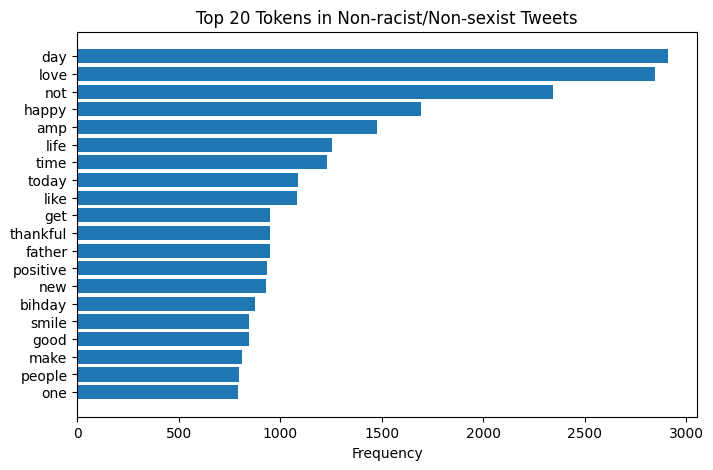

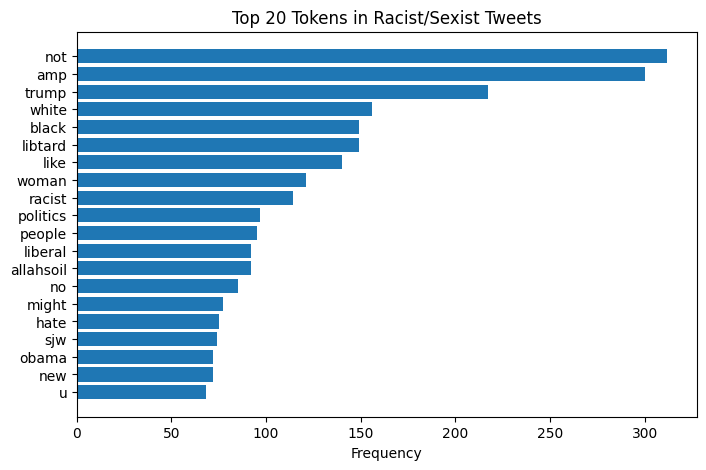

In [34]:
non_abusive_tokens = " ".join(processed_tweet_table[processed_tweet_table["label"] == 0]["clean_message"]).split()
abusive_tokens = " ".join(processed_tweet_table[processed_tweet_table["label"] == 1]["clean_message"]).split()

common_non_abusive = Counter(non_abusive_tokens).most_common(20)
common_abusive = Counter(abusive_tokens).most_common(20)

plt.figure(figsize=(8, 5))
words, counts = zip(*common_non_abusive[::-1])
plt.barh(words, counts)
plt.title("Top 20 Tokens in Non-racist/Non-sexist Tweets")
plt.xlabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
words, counts = zip(*common_abusive[::-1])
plt.barh(words, counts)
plt.title("Top 20 Tokens in Racist/Sexist Tweets")
plt.xlabel("Frequency")
plt.show()

## 6. Train-Test Split, Tokenization and Padding

The labelled dataset is split into 80% training and 20% testing data with stratification, so both sets keep a similar class ratio. Tokenization is fitted only on the training text to avoid data leakage. A percentile-based sequence length is used so that unusually long tweets do not force excessive padding.

In [35]:
train_messages, holdout_messages, train_targets, holdout_targets = train_test_split(
    processed_tweet_table["clean_message"].values,
    processed_tweet_table["label"].values,
    test_size=0.20,
    random_state=RANDOM_STATE_VALUE,
    stratify=processed_tweet_table["label"].values,
)

print("Training texts:", len(train_messages))
print("Testing texts:", len(holdout_messages))
print("Training class counts:", np.bincount(train_targets))
print("Testing class counts:", np.bincount(holdout_targets))

Training texts: 25541
Testing texts: 6386
Training class counts: [23750  1791]
Testing class counts: [5938  448]


In [36]:
VOCABULARY_CEILING = 12000
UNKNOWN_TOKEN = "<UNK>"
PADDING_PERCENTILE = 90

text_vectorizer = Tokenizer(num_words=VOCABULARY_CEILING, oov_token=UNKNOWN_TOKEN)
text_vectorizer.fit_on_texts(train_messages)

train_token_sequences = text_vectorizer.texts_to_sequences(train_messages)
holdout_token_sequences = text_vectorizer.texts_to_sequences(holdout_messages)

sequence_lengths = [len(sequence) for sequence in train_token_sequences]
SEQUENCE_LENGTH_CAP = max(8, int(np.percentile(sequence_lengths, PADDING_PERCENTILE)))

train_matrix = pad_sequences(
    train_token_sequences,
    maxlen=SEQUENCE_LENGTH_CAP,
    padding="post",
    truncating="post",
)
holdout_matrix = pad_sequences(
    holdout_token_sequences,
    maxlen=SEQUENCE_LENGTH_CAP,
    padding="post",
    truncating="post",
)

vocabulary_size_used = min(VOCABULARY_CEILING, len(text_vectorizer.word_index) + 1)

print("Vocabulary size used:", vocabulary_size_used)
print("Selected sequence length:", SEQUENCE_LENGTH_CAP)
print("Training matrix shape:", train_matrix.shape)
print("Testing matrix shape:", holdout_matrix.shape)

Vocabulary size used: 12000
Selected sequence length: 12
Training matrix shape: (25541, 12)
Testing matrix shape: (6386, 12)


In [37]:
# Class weights reduce the effect of class imbalance during model training.
balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_targets),
    y=train_targets,
)
training_class_weights = {label: weight for label, weight in enumerate(balanced_weights)}
training_class_weights

{0: np.float64(0.5377052631578947), 1: np.float64(7.13037409268565)}

## 7. Shared Training and Evaluation Utilities

The helper functions below keep the training, plotting and evaluation process consistent for all models. Accuracy, precision, recall, F1-score, classification report and confusion matrix are reported for comparison.

In [38]:
BATCH_QUANTITY = 96
MAX_EPOCHS = 8
VALIDATION_PORTION = 0.20


def fresh_early_stop_callback():
    return callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        verbose=1,
    )


def draw_training_curves(training_record, heading):
    history_values = training_record.history
    plt.figure(figsize=(7, 4))
    plt.plot(history_values["loss"], label="Training loss")
    plt.plot(history_values["val_loss"], label="Validation loss")
    plt.title(f"{heading}: Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_values["accuracy"], label="Training accuracy")
    plt.plot(history_values["val_accuracy"], label="Validation accuracy")
    plt.title(f"{heading}: Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


def assess_classifier(model_object, feature_matrix, actual_labels, title):
    predicted_probabilities = model_object.predict(feature_matrix, verbose=0).ravel()
    predicted_labels = (predicted_probabilities >= 0.50).astype(int)

    print(f"\nClassification report for {title}")
    print(classification_report(actual_labels, predicted_labels, target_names=["Not racist/sexist", "Racist/sexist"]))

    matrix = confusion_matrix(actual_labels, predicted_labels)
    ConfusionMatrixDisplay(matrix, display_labels=["Not racist/sexist", "Racist/sexist"]).plot(values_format="d")
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

    return predicted_labels, predicted_probabilities


def metric_row(model_name, true_labels, predicted_labels, elapsed_seconds):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(true_labels, predicted_labels), 4),
        "Precision_RacistSexist": round(precision_score(true_labels, predicted_labels, zero_division=0), 4),
        "Recall_RacistSexist": round(recall_score(true_labels, predicted_labels, zero_division=0), 4),
        "F1_RacistSexist": round(f1_score(true_labels, predicted_labels, zero_division=0), 4),
        "Training_Time_Seconds": round(elapsed_seconds, 2),
    }

model_metric_records = []
prediction_store = {}

## 8. Model 1: Simple RNN with Trainable Embedding

The first model is a baseline recurrent network. It learns word embeddings directly from the training dataset and uses a SimpleRNN layer to process the tweet sequence.

In [39]:
def create_vanilla_rnn_classifier(vocab_size, sequence_length, embedding_width=72):
    return keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_width, input_length=sequence_length),
        layers.SpatialDropout1D(0.20),
        layers.SimpleRNN(48, dropout=0.20, recurrent_dropout=0.10),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(1, activation="sigmoid"),
    ], name="simple_rnn_trainable_embedding")

vanilla_rnn_model = create_vanilla_rnn_classifier(vocabulary_size_used, SEQUENCE_LENGTH_CAP)
vanilla_rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
vanilla_rnn_model.summary()

Model: "simple_rnn_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
start_time = time.time()
vanilla_rnn_history = vanilla_rnn_model.fit(
    train_matrix,
    train_targets,
    validation_split=VALIDATION_PORTION,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_QUANTITY,
    class_weight=training_class_weights,
    callbacks=[fresh_early_stop_callback()],
    verbose=1,
)
vanilla_rnn_seconds = time.time() - start_time

print("Simple RNN training time:", round(vanilla_rnn_seconds, 2), "seconds")

Epoch 1/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7779 - loss: 0.5334 - val_accuracy: 0.8937 - val_loss: 0.3084
Epoch 2/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9048 - loss: 0.2718 - val_accuracy: 0.9147 - val_loss: 0.2315
Epoch 3/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9481 - loss: 0.1567 - val_accuracy: 0.9201 - val_loss: 0.2409
Epoch 4/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9634 - loss: 0.1012 - val_accuracy: 0.9366 - val_loss: 0.2292
Epoch 5/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9776 - loss: 0.0689 - val_accuracy: 0.9186 - val_loss: 0.2542
Epoch 6/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9794 - loss: 0.0605 - val_accuracy: 0.9289 - val_loss: 0.2874
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 4.
Simple RNN training time: 30.45 seconds


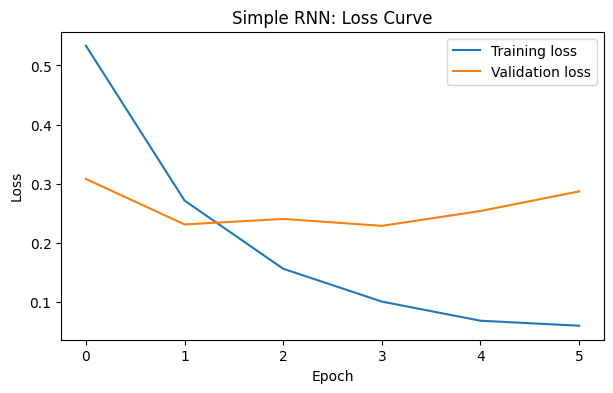

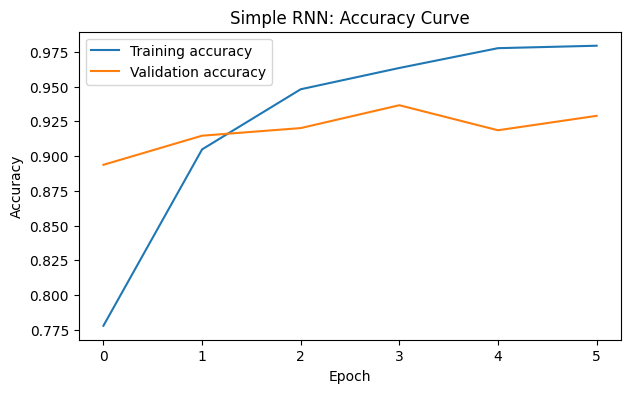


Classification report for Simple RNN
                   precision    recall  f1-score   support

Not racist/sexist       0.98      0.96      0.97      5938
    Racist/sexist       0.58      0.70      0.63       448

         accuracy                           0.94      6386
        macro avg       0.78      0.83      0.80      6386
     weighted avg       0.95      0.94      0.95      6386



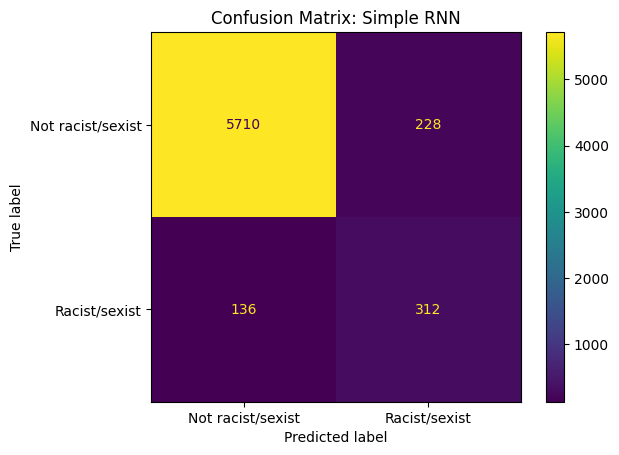

In [41]:
draw_training_curves(vanilla_rnn_history, "Simple RNN")
rnn_labels, rnn_scores = assess_classifier(vanilla_rnn_model, holdout_matrix, holdout_targets, "Simple RNN")
model_metric_records.append(metric_row("Simple RNN", holdout_targets, rnn_labels, vanilla_rnn_seconds))
prediction_store["Simple RNN"] = (rnn_labels, rnn_scores)

## 9. Model 2: LSTM with Trainable Embedding

The second model uses an LSTM layer instead of a SimpleRNN layer. LSTM units are better at controlling information flow through gates, which can help with vanishing-gradient problems in sequence learning.

In [42]:
def create_lstm_classifier(vocab_size, sequence_length, embedding_width=96):
    return keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_width, input_length=sequence_length),
        layers.SpatialDropout1D(0.25),
        layers.LSTM(64, dropout=0.25, recurrent_dropout=0.10),
        layers.Dense(48, activation="relu"),
        layers.Dropout(0.35),
        layers.Dense(1, activation="sigmoid"),
    ], name="lstm_trainable_embedding")

trainable_lstm_model = create_lstm_classifier(vocabulary_size_used, SEQUENCE_LENGTH_CAP)
trainable_lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
trainable_lstm_model.summary()

Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
start_time = time.time()
trainable_lstm_history = trainable_lstm_model.fit(
    train_matrix,
    train_targets,
    validation_split=VALIDATION_PORTION,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_QUANTITY,
    class_weight=training_class_weights,
    callbacks=[fresh_early_stop_callback()],
    verbose=1,
)
trainable_lstm_seconds = time.time() - start_time

print("Trainable LSTM training time:", round(trainable_lstm_seconds, 2), "seconds")

Epoch 1/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8511 - loss: 0.4848 - val_accuracy: 0.8804 - val_loss: 0.2891
Epoch 2/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9208 - loss: 0.2423 - val_accuracy: 0.9115 - val_loss: 0.2268
Epoch 3/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9482 - loss: 0.1581 - val_accuracy: 0.9289 - val_loss: 0.2072
Epoch 4/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9613 - loss: 0.1061 - val_accuracy: 0.9391 - val_loss: 0.2196
Epoch 5/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9714 - loss: 0.0764 - val_accuracy: 0.9374 - val_loss: 0.2289
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
Trainable LSTM training time: 49.93 seconds


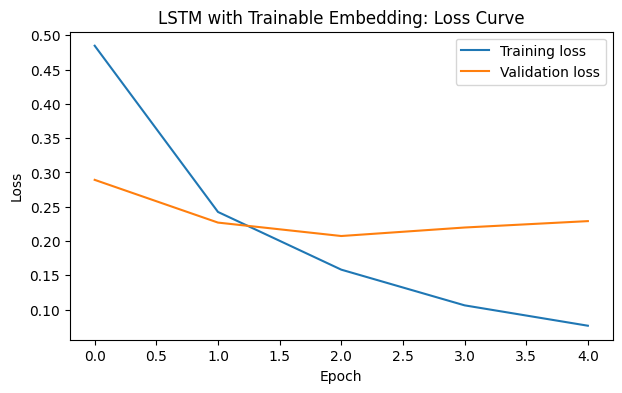

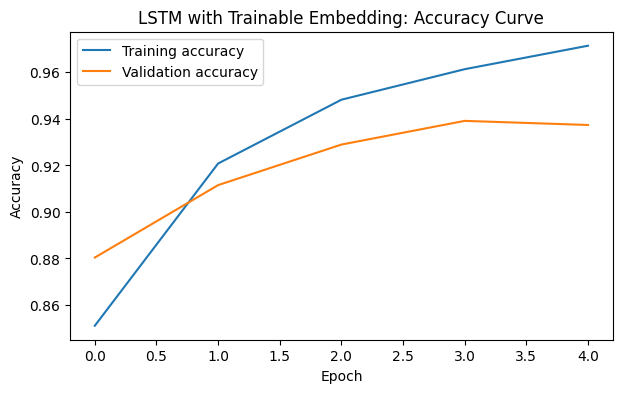


Classification report for LSTM with Trainable Embedding
                   precision    recall  f1-score   support

Not racist/sexist       0.98      0.95      0.96      5938
    Racist/sexist       0.52      0.73      0.61       448

         accuracy                           0.93      6386
        macro avg       0.75      0.84      0.79      6386
     weighted avg       0.95      0.93      0.94      6386



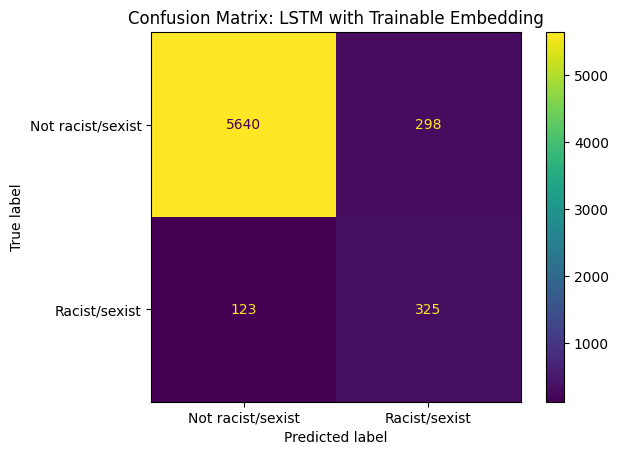

In [44]:
draw_training_curves(trainable_lstm_history, "LSTM with Trainable Embedding")
lstm_labels, lstm_scores = assess_classifier(trainable_lstm_model, holdout_matrix, holdout_targets, "LSTM with Trainable Embedding")
model_metric_records.append(metric_row("LSTM Trainable", holdout_targets, lstm_labels, trainable_lstm_seconds))
prediction_store["LSTM Trainable"] = (lstm_labels, lstm_scores)

## 10. Model 3: LSTM with Pretrained GloVe/Word2Vec-style Embeddings

The third model uses pretrained word vectors loaded through `gensim`. Because the dataset contains tweets, `glove-twitter-50` is selected as the pretrained embedding source. The embedding layer is initialized with these vectors and frozen during initial training to test whether external semantic knowledge improves performance.

In [45]:
# Install gensim only when it is not already available.
try:
    import gensim.downloader as api
except Exception:
    !pip install -q gensim
    import gensim.downloader as api

PRETRAINED_VECTOR_NAME = "glove-twitter-50"
print("Loading pretrained embeddings:", PRETRAINED_VECTOR_NAME)
pretrained_vectors = api.load(PRETRAINED_VECTOR_NAME)
print("Embedding dimension:", pretrained_vectors.vector_size)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.5 MB/s eta 0:00:00
Loading pretrained embeddings: glove-twitter-50
[==================================================] 100.0% 199.5/199.5MB downloaded
Embedding dimension: 50


In [46]:
PRETRAINED_DIMENSION = pretrained_vectors.vector_size
word_to_index_map = text_vectorizer.word_index

pretrained_embedding_matrix = np.zeros((vocabulary_size_used, PRETRAINED_DIMENSION))
covered_word_count = 0

for word, index_value in word_to_index_map.items():
    if index_value >= vocabulary_size_used:
        continue
    if word in pretrained_vectors:
        pretrained_embedding_matrix[index_value] = pretrained_vectors[word]
        covered_word_count += 1

coverage_ratio = covered_word_count / max(1, vocabulary_size_used - 1)
print("Vocabulary items covered by pretrained vectors:", covered_word_count)
print("Coverage ratio:", round(coverage_ratio, 4))

Vocabulary items covered by pretrained vectors: 10562
Coverage ratio: 0.8802


In [47]:
def create_pretrained_lstm_classifier(vocab_size, sequence_length, embedding_matrix, embedding_width):
    return keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_width,
            weights=[embedding_matrix],
            input_length=sequence_length,
            trainable=False,
        ),
        layers.SpatialDropout1D(0.15),
        layers.LSTM(72, dropout=0.20, recurrent_dropout=0.10),
        layers.Dense(40, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(1, activation="sigmoid"),
    ], name="lstm_pretrained_embedding")

pretrained_lstm_model = create_pretrained_lstm_classifier(
    vocabulary_size_used,
    SEQUENCE_LENGTH_CAP,
    pretrained_embedding_matrix,
    PRETRAINED_DIMENSION,
)
pretrained_lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
pretrained_lstm_model.summary()

Model: "lstm_pretrained_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,000 (2.29 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 600,000 (2.29 MB)

In [48]:
start_time = time.time()
pretrained_lstm_history = pretrained_lstm_model.fit(
    train_matrix,
    train_targets,
    validation_split=VALIDATION_PORTION,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_QUANTITY,
    class_weight=training_class_weights,
    callbacks=[fresh_early_stop_callback()],
    verbose=1,
)
pretrained_lstm_seconds = time.time() - start_time

print("Pretrained LSTM training time:", round(pretrained_lstm_seconds, 2), "seconds")

Epoch 1/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.7770 - loss: 0.4929 - val_accuracy: 0.8054 - val_loss: 0.3892
Epoch 2/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.7927 - loss: 0.4263 - val_accuracy: 0.8011 - val_loss: 0.3845
Epoch 3/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8027 - loss: 0.4071 - val_accuracy: 0.8293 - val_loss: 0.3472
Epoch 4/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8110 - loss: 0.3820 - val_accuracy: 0.8373 - val_loss: 0.3296
Epoch 5/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8258 - loss: 0.3629 - val_accuracy: 0.8227 - val_loss: 0.3588
Epoch 6/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8287 - loss: 0.3522 - val_accuracy: 0.8469 - val_loss: 0.3245
Epoch 7/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8402 - loss: 0.3454 - val_accuracy: 0.8503 - val_loss: 0.3114
Epoch 8/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8380 - loss: 0.3255 - val_accuracy: 

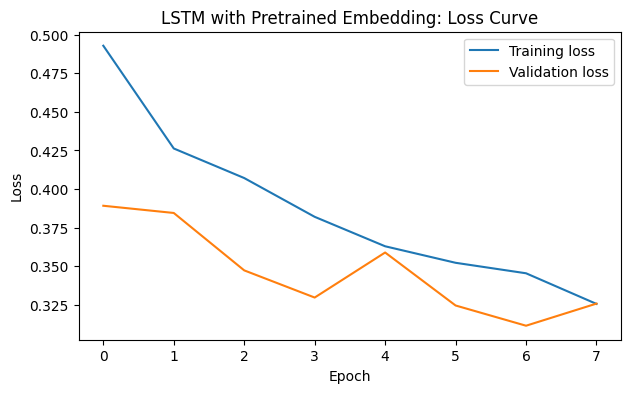

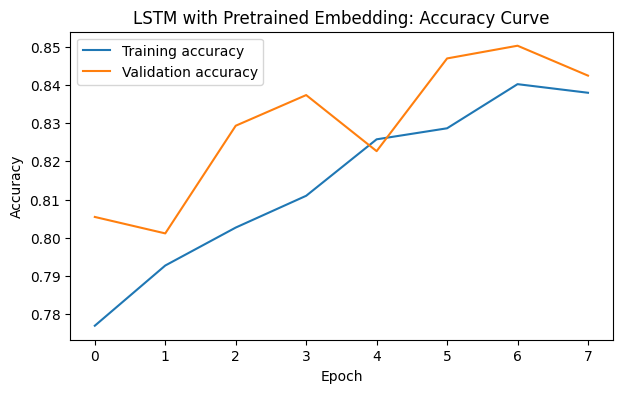


Classification report for LSTM with Pretrained Embedding
                   precision    recall  f1-score   support

Not racist/sexist       0.99      0.86      0.92      5938
    Racist/sexist       0.33      0.88      0.48       448

         accuracy                           0.87      6386
        macro avg       0.66      0.87      0.70      6386
     weighted avg       0.94      0.87      0.89      6386



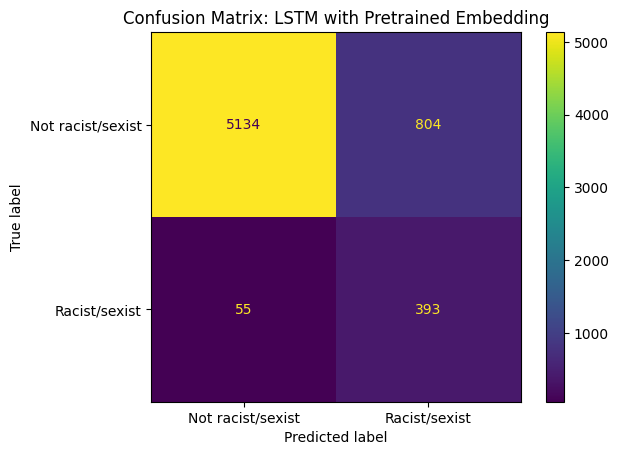

In [49]:
draw_training_curves(pretrained_lstm_history, "LSTM with Pretrained Embedding")
pretrained_labels, pretrained_scores = assess_classifier(pretrained_lstm_model, holdout_matrix, holdout_targets, "LSTM with Pretrained Embedding")
model_metric_records.append(metric_row("LSTM Pretrained", holdout_targets, pretrained_labels, pretrained_lstm_seconds))
prediction_store["LSTM Pretrained"] = (pretrained_labels, pretrained_scores)

## 11. Comparative Results

The following table compares all three Task 3 models using the same holdout test set. The racist/sexist class is emphasized through precision, recall and F1-score because it is the minority and higher-risk class.

In [50]:
comparison_results = pd.DataFrame(model_metric_records)
comparison_results.sort_values(by="F1_RacistSexist", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision_RacistSexist,Recall_RacistSexist,F1_RacistSexist,Training_Time_Seconds
0,Simple RNN,0.9430,0.5778,0.6964,0.6316,30.45
1,LSTM Trainable,0.9341,0.5217,0.7254,0.6069,49.93
2,LSTM Pretrained,0.8655,0.3283,0.8772,0.4778,70.93


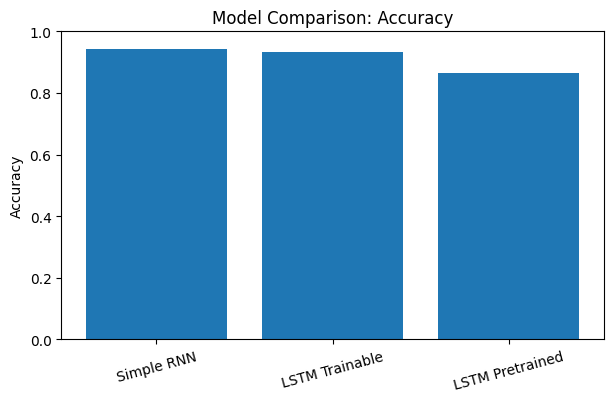

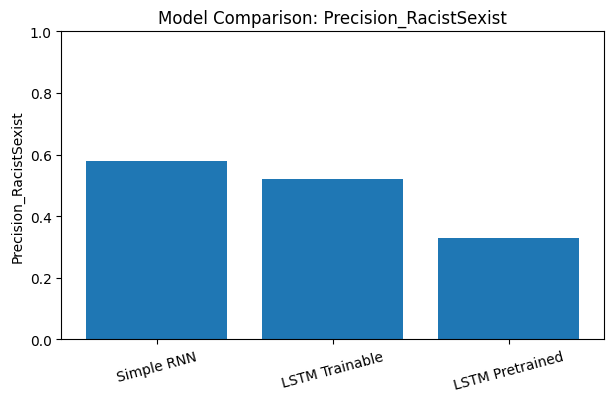

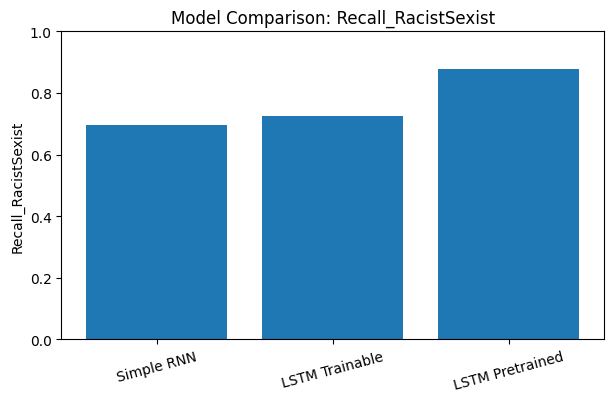

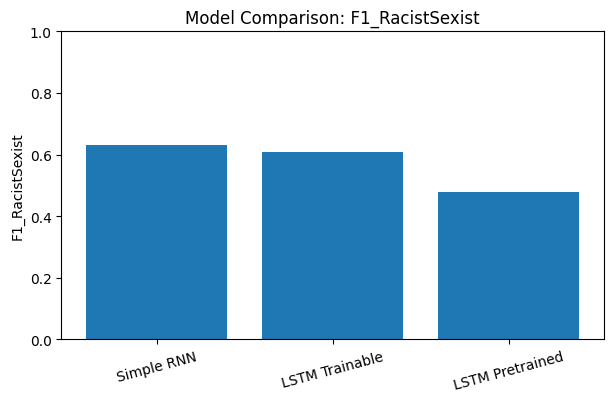

In [51]:
metric_columns = ["Accuracy", "Precision_RacistSexist", "Recall_RacistSexist", "F1_RacistSexist"]

for metric_name in metric_columns:
    plt.figure(figsize=(7, 4))
    plt.bar(comparison_results["Model"], comparison_results[metric_name])
    plt.title(f"Model Comparison: {metric_name}")
    plt.ylabel(metric_name)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.show()

## 12. Error Analysis

Misclassified examples are reviewed to understand model limitations. Errors may occur due to sarcasm, implicit hate speech, missing context, slang, or cases where offensive terms are quoted rather than used aggressively.

In [52]:
best_model_name = comparison_results.sort_values(by="F1_RacistSexist", ascending=False).iloc[0]["Model"]
best_predictions, best_probabilities = prediction_store[best_model_name]

print("Best model selected for error analysis:", best_model_name)

misclassified_positions = np.where(best_predictions != holdout_targets)[0]
print("Total misclassified examples:", len(misclassified_positions))

error_preview = []
for position in misclassified_positions[:5]:
    error_preview.append({
        "Cleaned Tweet": holdout_messages[position],
        "Actual Label": int(holdout_targets[position]),
        "Predicted Label": int(best_predictions[position]),
        "Predicted Probability": round(float(best_probabilities[position]), 4),
    })

pd.DataFrame(error_preview)

Best model selected for error analysis: Simple RNN
Total misclassified examples: 364


,Cleaned Tweet,Actual Label,Predicted Label,Predicted Probability
0,stop shit iphones reason keep like fuckin ipho...,0,1,0.9113
1,no matter opinion hate no place world time tea...,0,1,0.7200
2,waiting somebody call not see anybody,1,0,0.0303
3,need let go brazilian black goodnight picofthe...,0,1,0.9057
4,not good preventabletragedy,0,1,0.5315


### Error Observation

The model can still confuse borderline tweets because social-media text is short, informal and often context dependent. Some tweets may contain offensive vocabulary without being targeted abuse, while others express harmful intent indirectly. Future improvement could include transformer-based models, more advanced text augmentation, additional labelled examples and threshold tuning for the minority class.

## 13. Real-Time Prediction Interface

The assessment suggests a simple GUI as an extra challenge. The cell below creates a Gradio interface that cleans a user-entered tweet, tokenizes it using the fitted tokenizer and predicts whether the text is racist/sexist.

In [53]:
# Uncomment the install line if Gradio is not available in Colab.
# !pip install -q gradio

try:
    import gradio as gr

    # Use the best-performing model automatically.
    selected_model_name = best_model_name
    model_lookup = {
        "Simple RNN": vanilla_rnn_model,
        "LSTM Trainable": trainable_lstm_model,
        "LSTM Pretrained": pretrained_lstm_model,
    }
    live_prediction_model = model_lookup[selected_model_name]

    def classify_live_tweet(user_text):
        cleaned_text = normalize_tweet_text(user_text)
        sequence = text_vectorizer.texts_to_sequences([cleaned_text])
        padded_sequence = pad_sequences(sequence, maxlen=SEQUENCE_LENGTH_CAP, padding="post", truncating="post")
        probability = float(live_prediction_model.predict(padded_sequence, verbose=0).ravel()[0])
        label = "Racist/Sexist" if probability >= 0.50 else "Not Racist/Sexist"
        return {
            "cleaned_text": cleaned_text,
            "prediction": label,
            "racist_sexist_probability": round(probability, 4),
            "model_used": selected_model_name,
        }

    demo = gr.Interface(
        fn=classify_live_tweet,
        inputs=gr.Textbox(lines=4, label="Enter a tweet"),
        outputs=gr.JSON(label="Prediction output"),
        title="Racist/Sexist Tweet Classifier",
        description="Type a tweet to receive a real-time binary prediction from the best trained model.",
    )

    demo.launch(share=False)
except Exception as gui_error:
    print("Gradio interface could not be launched in this environment:", gui_error)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 14. Notes for Report Writing

This notebook supports the Task 3 report sections by providing dataset description, preprocessing details, tokenization and padding settings, RNN/LSTM model architectures, pretrained embedding usage, performance comparisons, error analysis and a real-time prediction interface. The final report should discuss the trade-off between model complexity, minority-class recall and computational cost.